# Kwadratury - część II

Notebook zawiera rozwiązania trzech zadań z wykorzystaniem kwadratur numerycznych. Każde zadanie jest oddzielone osobną sekcją, a ważniejsze etapy obliczeń są opisane przed kodem.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import integrate, special

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
})

Matplotlib is building the font cache; this may take a moment.


## Zadanie 1 - prędkość strzały

Energia kinetyczna strzały jest równa pracy wykonanej podczas naciągania łuku:

$$\frac{1}{2}mv^2 = \int_0^L F(x)\,dx.$$

Dane siły są podane w równych odstępach `h = 0.05 m`, dlatego można bezpośrednio użyć złożonej metody trapezów i złożonej metody Simpsona. Ponieważ liczba podprzedziałów wynosi 10, metoda Simpsona jest tu naturalnym wyborem o wyższym rzędzie dokładności.

,metoda,praca [J],predkosc [m/s]
0,trapezy,74.400000,44.542115
1,Simpson,74.533333,44.582009


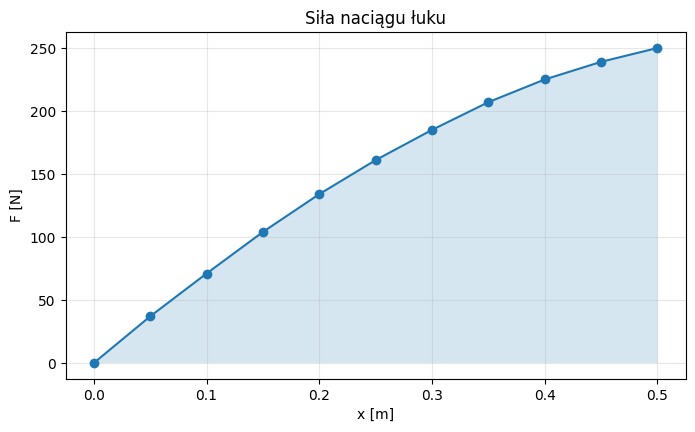

Praca metodą Simpsona: 74.533333 J
Prędkość strzały: 44.582009 m/s


In [2]:
x = np.array([0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50])
F = np.array([0, 37, 71, 104, 134, 161, 185, 207, 225, 239, 250], dtype=float)
m_arrow = 0.075
h = x[1] - x[0]

work_trapezoid = integrate.trapezoid(F, x)
work_simpson = integrate.simpson(F, x=x)
v_trapezoid = np.sqrt(2 * work_trapezoid / m_arrow)
v_simpson = np.sqrt(2 * work_simpson / m_arrow)

task1_results = pd.DataFrame({
    "metoda": ["trapezy", "Simpson"],
    "praca [J]": [work_trapezoid, work_simpson],
    "predkosc [m/s]": [v_trapezoid, v_simpson],
})
display(task1_results)

plt.plot(x, F, "o-")
plt.fill_between(x, F, alpha=0.18)
plt.xlabel("x [m]")
plt.ylabel("F [N]")
plt.title("Siła naciągu łuku")
plt.show()

print(f"Praca metodą Simpsona: {work_simpson:.6f} J")
print(f"Prędkość strzały: {v_simpson:.6f} m/s")

## Zadanie 2 - ciało na pręcie i sprężyna

W punkcie (a) obliczamy prędkość z zależności:

$$v_0 = \sqrt{2\int_0^l f(x)\,dx},$$

gdzie

$$f(x)=\mu g + \frac{k}{m}(\mu l + x)\left(1 - \frac{l}{\sqrt{l^2+x^2}}\right).$$

W punkcie (b) całka na stałą `C` ma osobliwość całkowalną przy `z = 1`. Dlatego liczymy ją na dwa sposoby: bezpośrednio przez `quad` z zaznaczeniem punktu osobliwego oraz po podstawieniu `z = 1 - u^2`, które usuwa czynnik typu `(1-z)^(-1/2)`.

In [3]:
m = 0.8
l = 0.4
mu = 0.3
k_spring = 80.0
g = 9.81

def f_task2(x):
    return mu * g + (k_spring / m) * (mu * l + x) * (1 - l / np.sqrt(l**2 + x**2))

# Zgodnie z treścią zadania całkujemy od 0 do l, a nie od 0 do 1.
integral_f, error_f = integrate.quad(f_task2, 0, l, epsabs=1e-12, epsrel=1e-12)
v0 = np.sqrt(2 * integral_f)

def c_integrand(z):
    # Wzór z zadania zawiera sqrt(1 + z), a nie sqrt(1 + z**2).
    value = (np.sqrt(2) - 1)**2 - (np.sqrt(1 + z) - 1)**2
    return value**(-0.5)

C_direct, error_C_direct = integrate.quad(
    c_integrand, 0, 1, points=[1], epsabs=1e-12, epsrel=1e-12, limit=300
)

def c_integrand_after_substitution(u):
    # Podstawienie z = 1 - u^2 usuwa osobliwość w z = 1.
    if np.isclose(u, 0.0):
        # Granica funkcji po podstawieniu dla u -> 0.
        return 2 * np.sqrt(np.sqrt(2) / (np.sqrt(2) - 1))
    z = 1 - u**2
    return 2 * u * c_integrand(z)

C_substitution, error_C_substitution = integrate.quad(
    c_integrand_after_substitution, 0, 1, epsabs=1e-12, epsrel=1e-12, limit=300
)
t_direct = C_direct * np.sqrt(m / k_spring)
t_substitution = C_substitution * np.sqrt(m / k_spring)

task2_results = pd.DataFrame({
    "wielkosc": [
        "int_0^l f(x) dx",
        "v0",
        "C bezposrednio",
        "C po podstawieniu",
        "t bezposrednio",
        "t po podstawieniu",
    ],
    "wartosc": [integral_f, v0, C_direct, C_substitution, t_direct, t_substitution],
})
display(task2_results)
print(f"Prędkość v0 = {v0:.6f} m/s")
print(f"C = {C_substitution:.12f}")
print(f"Czas t = {t_substitution:.6f} s")

,wielkosc,wartosc
0,int_0^l f(x) dx,3.119190
1,v0,2.497675
2,C bezposrednio,3.970020
3,C po podstawieniu,3.970020
4,t bezposrednio,0.397002
5,t po podstawieniu,0.397002


Prędkość v0 = 2.497675 m/s
C = 3.970019778336
Czas t = 0.397002 s


## Zadanie 3 - okres wahadła matematycznego

Dla małych wychyleń używa się wzoru:

$$T_0 = 2\pi\sqrt{\frac{l}{g}}.$$

Dla dowolnego wychylenia początkowego okres wyraża się przez całkę eliptyczną pierwszego rodzaju:

$$T(\theta_0)=4\sqrt{\frac{l}{g}}K(k),\qquad k=\sin\frac{\theta_0}{2}.$$

Najpierw obliczamy `K(k)` dla `theta0 = 45°` przez standardową kwadraturę i porównujemy wynik z funkcją `scipy.special.ellipk`. W SciPy argument funkcji `ellipk` jest parametrem `m = k^2`, a nie samym modułem `k`.

In [4]:
pendulum_l = 1.0
theta0_deg = 45.0
theta0 = np.deg2rad(theta0_deg)
k_mod = np.sin(theta0 / 2)

def elliptic_integrand(theta, k_value):
    return 1 / np.sqrt(1 - k_value**2 * np.sin(theta)**2)

K_quad, error_K_quad = integrate.quad(
    elliptic_integrand, 0, np.pi / 2, args=(k_mod,), epsabs=1e-12, epsrel=1e-12
)
K_scipy = special.ellipk(k_mod**2)
T_quad = 4 * np.sqrt(pendulum_l / g) * K_quad
T_scipy = 4 * np.sqrt(pendulum_l / g) * K_scipy
T_small = 2 * np.pi * np.sqrt(pendulum_l / g)

pd.DataFrame({
    "metoda": ["quad", "scipy.special.ellipk", "wzor malych wychylen"],
    "K": [K_quad, K_scipy, np.pi / 2],
    "T [s]": [T_quad, T_scipy, T_small],
    "blad wzgledem scipy": [abs(K_quad - K_scipy) / abs(K_scipy), 0.0, abs(T_small - T_scipy) / abs(T_scipy)],
})

,metoda,K,T [s],blad wzgledem scipy
0,quad,1.633586,2.086256,1.359246e-16
1,scipy.special.ellipk,1.633586,2.086256,0.000000e+00
2,wzor malych wychylen,1.570796,2.006067,3.843689e-02


### Metoda AGM

W poleceniu metoda AGM jest zapisana jako start z `a0 = 1 + k` oraz `b0 = 1 - k`, a następnie:

$$K(k) \approx \frac{\pi}{2\operatorname{AGM}_n(1+k,1-k)}.$$

Ta postać jest równoważna klasycznej postaci z `AGM(1, sqrt(1-k^2))`, ale dla skończonej liczby iteracji daje inny przebieg błędu, dlatego w kodzie poniżej stosujemy dokładnie zapis z polecenia.

,liczba iteracji,K_AGM,blad wzgledny
0,0,1.136049,3.045674e-01
1,1,1.570796,3.843689e-02
2,2,1.632947,3.915613e-04
3,3,1.633586,3.835258e-08
4,4,1.633586,4.077739e-16
5,5,1.633586,0.000000e+00
6,6,1.633586,0.000000e+00
7,7,1.633586,0.000000e+00


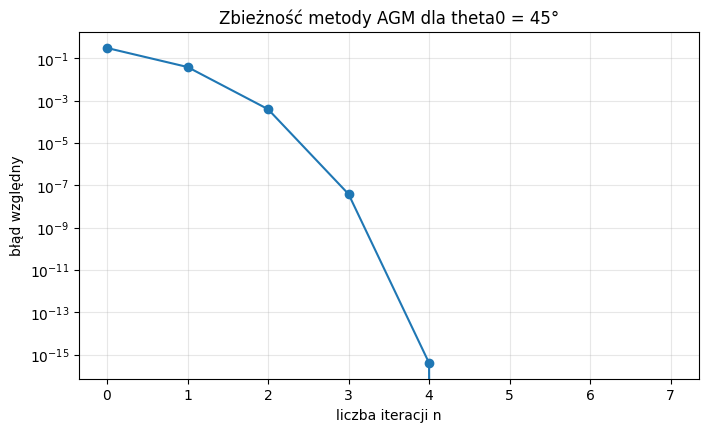

In [5]:
def agm_approximation(k_value, iterations):
    # Wersja zgodna z wzorem (12): AGM(1 + k, 1 - k).
    a = 1 + k_value
    b = 1 - k_value
    for _ in range(iterations):
        a, b = (a + b) / 2, np.sqrt(a * b)
    return np.pi / (2 * a)

iterations = np.arange(0, 8)
K_agm_values = np.array([agm_approximation(k_mod, n) for n in iterations])
relative_errors_agm = np.abs(K_agm_values - K_scipy) / np.abs(K_scipy)

display(pd.DataFrame({
    "liczba iteracji": iterations,
    "K_AGM": K_agm_values,
    "blad wzgledny": relative_errors_agm,
}))

plt.semilogy(iterations, relative_errors_agm, "o-")
plt.xlabel("liczba iteracji n")
plt.ylabel("błąd względny")
plt.title("Zbieżność metody AGM dla theta0 = 45°")
plt.xticks(iterations)
plt.show()

### Błąd wzoru małych wychyleń

Na końcu porównujemy okres z przybliżenia małych wychyleń z okresem eliptycznym dla `theta0` od `0°` do `90°` co `5°`. Błąd liczony jest względem pełnego wzoru z całką eliptyczną.

,theta0 [deg],T dokladne [s],T male wychylenia [s],blad wzgledny
0,0,2.006067,2.006067,0.000000
1,5,2.007022,2.006067,0.000476
2,10,2.009893,2.006067,0.001904
3,15,2.014694,2.006067,0.004282
4,20,2.021451,2.006067,0.007611
5,25,2.030201,2.006067,0.011888
6,30,2.040990,2.006067,0.017111
7,35,2.053878,2.006067,0.023279
8,40,2.068938,2.006067,0.030388
9,45,2.086256,2.006067,0.038437


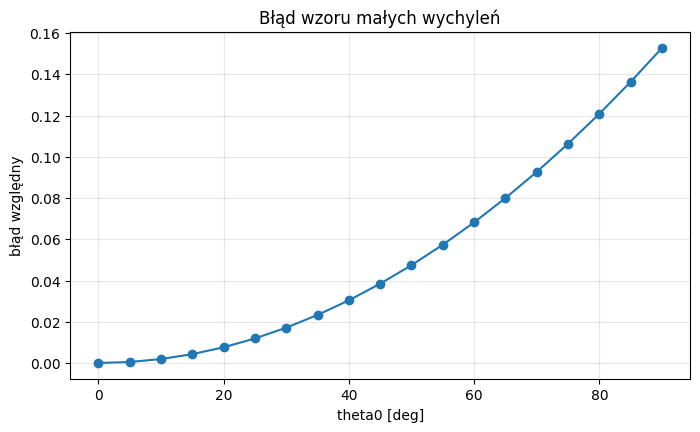

Błąd względny dla theta0 = 45°: 3.843689%
Błąd względny dla theta0 = 90°: 15.278692%


In [6]:
theta_degrees = np.arange(0, 91, 5)
theta_radians = np.deg2rad(theta_degrees)
k_values = np.sin(theta_radians / 2)
K_values = special.ellipk(k_values**2)
T_exact = 4 * np.sqrt(pendulum_l / g) * K_values
T_small_values = np.full_like(T_exact, T_small)
relative_errors_small_angle = np.abs(T_small_values - T_exact) / np.abs(T_exact)

display(pd.DataFrame({
    "theta0 [deg]": theta_degrees,
    "T dokladne [s]": T_exact,
    "T male wychylenia [s]": T_small_values,
    "blad wzgledny": relative_errors_small_angle,
}))

plt.plot(theta_degrees, relative_errors_small_angle, "o-")
plt.xlabel("theta0 [deg]")
plt.ylabel("błąd względny")
plt.title("Błąd wzoru małych wychyleń")
plt.show()

error_45 = relative_errors_small_angle[theta_degrees == 45][0]
error_90 = relative_errors_small_angle[theta_degrees == 90][0]
print(f"Błąd względny dla theta0 = 45°: {error_45:.6%}")
print(f"Błąd względny dla theta0 = 90°: {error_90:.6%}")

## Podsumowanie wyników

- Zadanie 1: praca wykonana przy naciąganiu łuku, liczona metodą Simpsona, wynosi około `74.533 J`, co daje prędkość strzały około `44.582 m/s`.
- Zadanie 2: po poprawnym całkowaniu po przedziale `[0, l]` prędkość ciała w punkcie `x = 0` wynosi około `2.498 m/s`. Stała `C` wynosi około `3.970020`, a czas przejścia od `x = l` do `x = 0` około `0.397 s`.
- Zadanie 3: dla `theta0 = 45°` metoda AGM bardzo szybko osiąga dokładność funkcji `ellipk`; przybliżenie małych wychyleń zaniża okres, a jego błąd rośnie wraz z amplitudą.